<!-- project-notebook-context -->
# Image Restoration Benchmark - Piecewise Contrast Mapping Legacy Notebook

**Current project:** `image-restoration-benchmark`

**Notebook role:** Legacy notebook for grayscale piecewise intensity mapping. The contrast-enhancement workflow is now integrated into the benchmark pipeline beside CLAHE and restoration methods.

## Current project entry points

- `image_restoration_benchmark/contrast.py`
- `scripts/run_benchmark.py`

## Maintenance notes

- This notebook is kept as historical method exploration.
- Use assets/example_outputs for publishable outputs.

---



In [1]:
import cv2 as cv
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# --- Reproducible-run setup (uses an open-source natural sample image) ---
import os, warnings
from pathlib import Path
import numpy as np
import cv2 as cv

warnings.filterwarnings('ignore')
_NB_DIR = Path.cwd()
_RUN_DIR = (_NB_DIR / '..' / 'outputs').resolve()
_RUN_DIR.mkdir(parents=True, exist_ok=True)
_SRC = (_NB_DIR / '../sample/coins.png').resolve()


def _prepare_input(name, max_side=160):
    img = cv.imread(str(_SRC))
    if img is None:
        raise FileNotFoundError(f'Natural sample image not found: {_SRC}')
    h, w = img.shape[:2]
    s = max_side / max(h, w)
    if s < 1.0:
        img = cv.resize(img, (int(w * s), int(h * s)), interpolation=cv.INTER_AREA)
    dst = _RUN_DIR / name
    cv.imwrite(str(dst), img)
    print('Using natural sample:', _SRC.name, '->', img.shape)
    return dst


_prepare_input('1.jpg')
os.chdir(_RUN_DIR)
print('Run dir:', _RUN_DIR)


Using natural sample: coins.png -> (126, 160, 3)
Run dir: C:\work\p\github-repos\private\image-restoration-benchmark\legacy\piecewise-contrast-mapping\outputs


In [3]:
f_path = '1.jpg' 
#file location

In [4]:
image = cv.imread(f_path,cv.IMREAD_GRAYSCALE)

In [5]:
cv.imwrite('image1.jpg', image)

True

In [6]:
image[0,0]

np.uint8(116)

In [7]:
image_height,image_width = image.shape[:2]

In [8]:
print(image_width,image_height)

160 126


In [9]:
gray_value = cv.calcHist([image], [0], None, [256], [0, 256])
#number calculate

In [10]:
print(gray_value[255])

[0.]


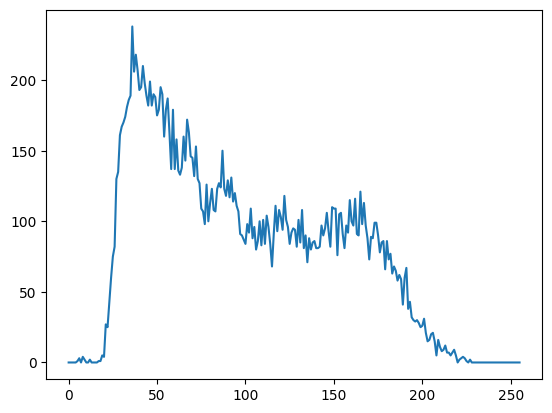

In [11]:
plt.plot(gray_value)
plt.show()

In [12]:
p = {}
caculate=0
for i in range(256) :
    p[i] = int(gray_value[i])/(image_width*image_height)

In [13]:
print(p[255])

0.0


In [14]:
sigmap = 0.0
sum_num = 0
for i in range(256):
    if (p[i] > 0):
        logp = p[i] * math.log2(p[i])
        sigmap += logp
        sum_num += 1
sigmap*= -1
entropy = sigmap/sum_num
print(entropy)
#entropy

0.034767933685198406


In [15]:
xMin = image.min() 
xMax = image.max()  
x1, y1 = xMin, 0  
x2, y2 = xMax, 255  

In [16]:
x1, y1 ,x2, y2

(np.uint8(5), 0, np.uint8(227), 255)

In [17]:
image2 = image.copy()
image_height2,image_width2= image2.shape[:2]

_low = (y1 / x1) if x1 else 0.0
_mid = ((y2 - y1) / (x2 - x1)) if (x2 - x1) else 0.0
_high = ((255. - y2) / (255. - x2)) if (255. - x2) else 0.0

for i in range(0,image_height2):
    for j in range(0, image_width2):
        if image2[i,j] <= x1:
            image2[i,j] = image2[i,j]*_low
        elif image2[i,j] <= x2:
            image2[i,j] = (image2[i,j]-x1)*_mid+x1
        else:
            image2[i,j] = (image2[i,j]-x2)*_high+x2

In [18]:
cv.imwrite('image2.jpg', image2)

True

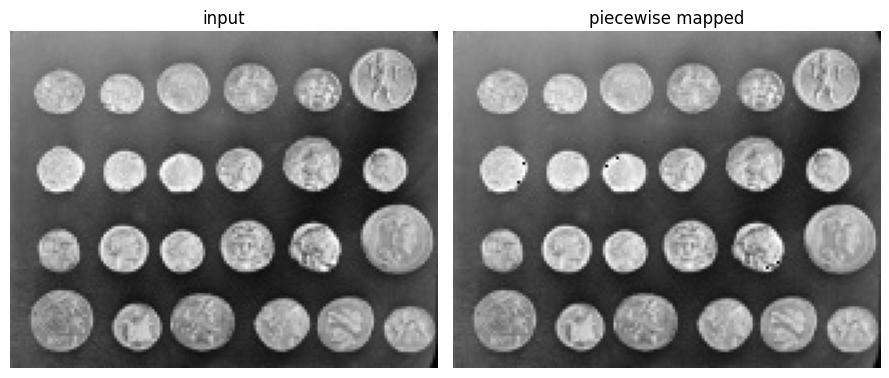

Artifacts written to C:\work\p\github-repos\private\image-restoration-benchmark\legacy\piecewise-contrast-mapping\outputs


In [19]:
import matplotlib.pyplot as plt
mapped = cv.imread('image2.jpg', cv.IMREAD_GRAYSCALE)
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(image, cmap='gray'); ax[0].set_title('input'); ax[0].axis('off')
ax[1].imshow(mapped, cmap='gray'); ax[1].set_title('piecewise mapped'); ax[1].axis('off')
plt.tight_layout(); plt.show()
print('Artifacts written to', _RUN_DIR)